In [3]:
!pip install pretty_midi pydub scipy

Using device: cpu
  Lo-Fi Beat Generator — LSTM + MIDI Synthesis

[1/5] Building training corpus …
      800 sequences | vocab: 11 chords

[2/5] Building LSTM model …
      Parameters: 267,019

[3/5] Training for 60 epochs …

  Epoch [ 10/60]  Loss: 0.0596  Time: 0.2min
  Epoch [ 20/60]  Loss: 0.0594  Time: 0.4min
  Epoch [ 30/60]  Loss: 0.0586  Time: 0.5min
  Epoch [ 40/60]  Loss: 0.0584  Time: 0.7min
  Epoch [ 50/60]  Loss: 0.0583  Time: 0.8min
  Epoch [ 60/60]  Loss: 0.0579  Time: 0.9min

  ✅ Training done in 0.9 min

[4/5] Plotting loss curve …


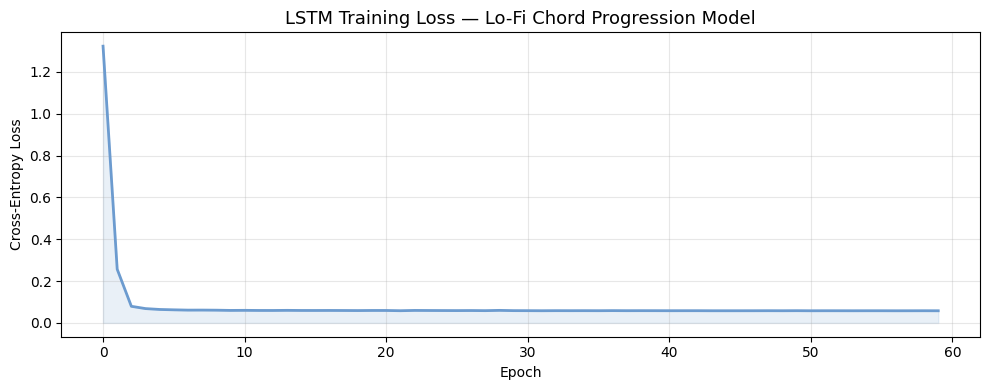

Loss curve saved → outputs/loss_curve.png

[5/5] Generating 2 lo-fi songs …

  🎵 Song 1  (seed chord: Cmaj7)
     Chords: Cmaj7 → Fmaj7 → Dm7 → G7 → Cmaj7 → Fmaj7 → Dm7 → G7 …
     MIDI → outputs/lofi_song_1.mid
  ✅  MP3 saved → outputs/lofi_song_1.mp3

  🎵 Song 2  (seed chord: Am7)
     Chords: Am7 → Dm7 → G7 → Cmaj7 → Am7 → Dm7 → G7 → Cmaj7 …
     MIDI → outputs/lofi_song_2.mid
  ✅  MP3 saved → outputs/lofi_song_2.mp3

  Done! Download the .mp3 files from the Colab file browser.
  Lo-Fi Beat Generator — LSTM + MIDI Synthesis

[1/5] Building training corpus …
      800 sequences | vocab: 11 chords

[2/5] Building LSTM model …
      Parameters: 267,019

[3/5] Training for 60 epochs …

  Epoch [ 10/60]  Loss: 0.0620  Time: 0.1min
  Epoch [ 20/60]  Loss: 0.0608  Time: 0.2min
  Epoch [ 30/60]  Loss: 0.0597  Time: 0.4min
  Epoch [ 40/60]  Loss: 0.0593  Time: 0.5min
  Epoch [ 50/60]  Loss: 0.0591  Time: 0.6min
  Epoch [ 60/60]  Loss: 0.0589  Time: 0.8min

  ✅ Training done in 0.8 min

[4/5]

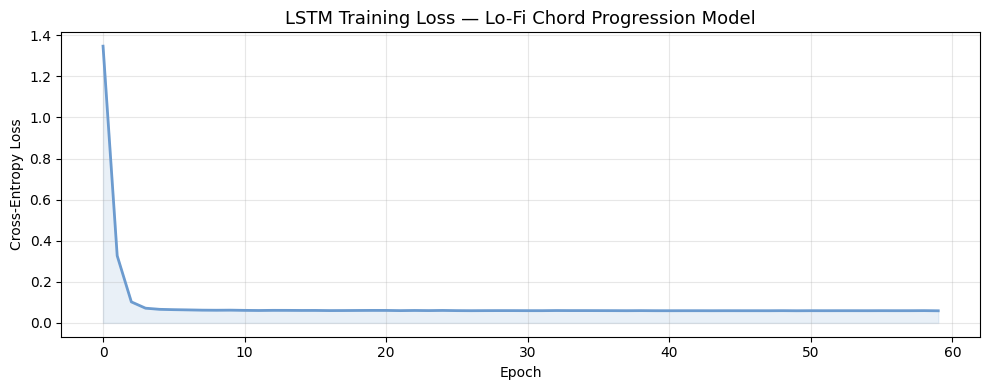

Loss curve saved → outputs/loss_curve.png

[5/5] Generating 2 lo-fi songs …

  🎵 Song 1  (seed chord: Cmaj7)
     Chords: Cmaj7 → Am7 → Dm7 → G7 → Cmaj7 → Am7 → Dm7 → G7 …
     MIDI → outputs/lofi_song_1.mid
  ✅  MP3 saved → outputs/lofi_song_1.mp3

  🎵 Song 2  (seed chord: Am7)
     Chords: Am7 → G7 → Fmaj7 → G7 → Am7 → G7 → Fmaj7 → G7 …
     MIDI → outputs/lofi_song_2.mid
  ✅  MP3 saved → outputs/lofi_song_2.mp3

  Done! Download the .mp3 files from the Colab file browser.


In [4]:
"""
Lo-Fi Beat Generator — LSTM + MIDI Synthesis
=============================================
Course  : 204466 Deep Learning — Final Project
Topic   : Generating lo-fi hip-hop beats using an LSTM RNN
Framework: PyTorch (Google Colab compatible)

What makes lo-fi sound like lo-fi?
-----------------------------------
  • Slow BPM (75–90)
  • Jazz chords: maj7, min7, dom7, min9
  • Boom-bap drum pattern: kick on 1&3, snare on 2&4, hi-hat 8ths
  • Rhodes/electric piano timbre (MIDI program 4)
  • Simple repeating chord progressions (ii–V–I, I–VI–IV–V)
  • Melody with lots of space (rests, long notes)

Deep Learning role
------------------
  The LSTM learns chord progressions and melody sequences from a
  hand-crafted lo-fi training corpus. After training it generates
  new chord + melody sequences that are then rendered to MP3.

Run this first in Colab (one-time setup):
  !pip install pretty_midi pydub
  !apt-get install -y timidity fluid-soundfont-gm ffmpeg
"""

# ─── Standard library ──────────────────────────────────────────────────────
import os, random, time

# ─── PyTorch ───────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ─── Audio / MIDI ──────────────────────────────────────────────────────────
import pretty_midi
import numpy as np
import matplotlib.pyplot as plt

# pydub for WAV → MP3 conversion
try:
    from pydub import AudioSegment
    PYDUB_AVAILABLE = True
except ImportError:
    PYDUB_AVAILABLE = False
    print("pydub not found — run: pip install pydub")


# ══════════════════════════════════════════════════════════════════════════
# 0.  CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════

BPM           = 80          # Lo-fi tempo (slow & laid-back)
BEATS_PER_BAR = 4
NUM_BARS      = 8           # Bars per generated song section
SONG_SECTIONS = 4           # Sections tiled together → longer song

# LSTM hyperparameters
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
SEQ_LENGTH    = 16          # Training sequence length in beats
BATCH_SIZE    = 32
NUM_EPOCHS    = 60          # ~10 min on Colab T4
LR            = 0.003

# Generation
TEMPERATURE   = 0.8         # < 1 = conservative, > 1 = more creative
NUM_SONGS     = 2           # MP3 files to produce

OUTPUT_DIR    = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)


# ══════════════════════════════════════════════════════════════════════════
# 1.  MUSIC THEORY — Lo-fi chord vocabulary
# ══════════════════════════════════════════════════════════════════════════

# MIDI note numbers. We work from C3 (48) as the base.
# Jazz chord voicings (7ths and 9ths) — these give lo-fi its warm, rich sound.
LOFI_CHORDS = {
    "Cmaj7":  [48, 52, 55, 59],          # C  E  G  B
    "Am7":    [45, 48, 52, 55],          # A  C  E  G
    "Dm7":    [50, 53, 57, 60],          # D  F  A  C
    "G7":     [43, 47, 50, 53],          # G  B  D  F
    "Fmaj7":  [41, 45, 48, 52],          # F  A  C  E
    "Em7":    [40, 43, 47, 50],          # E  G  B  D
    "Bm7b5":  [47, 50, 53, 57],          # B  D  F  A  (half-diminished)
    "Cmaj9":  [48, 52, 55, 59, 62],      # C  E  G  B  D
    "Am9":    [45, 48, 52, 55, 59],      # A  C  E  G  B
    "Dm9":    [50, 53, 57, 60, 64],      # D  F  A  C  E
    "Gmaj7":  [43, 47, 50, 54],          # G  B  D  F#
}

CHORD_NAMES   = list(LOFI_CHORDS.keys())
CHORD_TO_IDX  = {c: i for i, c in enumerate(CHORD_NAMES)}
IDX_TO_CHORD  = {i: c for c, i in CHORD_TO_IDX.items()}

# Common lo-fi chord progressions used to build the training corpus
LOFI_PROGRESSIONS = [
    ["Cmaj7", "Am7",   "Dm7",   "G7"],       # I – VI – II – V  (classic)
    ["Cmaj7", "Em7",   "Am7",   "Dm7"],       # I – III – VI – II
    ["Am7",   "Dm7",   "G7",    "Cmaj7"],     # II – V – I variation
    ["Cmaj7", "Fmaj7", "Dm7",   "G7"],        # I – IV – II – V
    ["Am9",   "Dm9",   "Gmaj7", "Cmaj9"],     # 9th chord richness
    ["Am7",   "G7",    "Fmaj7", "G7"],        # loop-friendly
    ["Cmaj7", "Bm7b5", "Am7",   "G7"],        # descending feel
    ["Fmaj7", "Em7",   "Dm7",   "Cmaj7"],     # descending I-chain
]

# Pentatonic / blues scale offsets for melody generation.
# A minor pentatonic sits naturally over most of these chords.
PENTATONIC_OFFSETS = [0, 3, 5, 7, 10, 12, 15, 17]
MELODY_ROOT        = 57   # A3 — sits nicely above the chords


# ══════════════════════════════════════════════════════════════════════════
# 2.  TRAINING DATA — Build chord sequences programmatically
# ══════════════════════════════════════════════════════════════════════════

def build_corpus(n_sequences: int = 800) -> list:
    """
    Create the training corpus by sampling and tiling the known lo-fi
    progressions into fixed-length sequences.

    Returns:
        List of integer-encoded chord sequences.
    """
    corpus = []
    for _ in range(n_sequences):
        prog = random.choice(LOFI_PROGRESSIONS)
        # Tile 4-chord progression to fill SEQ_LENGTH
        seq  = (prog * ((SEQ_LENGTH // len(prog)) + 2))[:SEQ_LENGTH]
        corpus.append([CHORD_TO_IDX[c] for c in seq])
    return corpus


class ChordDataset(Dataset):
    """
    Wraps the corpus into (input, target) pairs for next-chord prediction.
    Input  : chord indices [0 … SEQ_LENGTH-2]
    Target : chord indices [1 … SEQ_LENGTH-1]  (shifted by 1)
    """
    def __init__(self, corpus: list):
        self.samples = [
            (torch.tensor(seq[:-1], dtype=torch.long),
             torch.tensor(seq[1:],  dtype=torch.long))
            for seq in corpus
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# ══════════════════════════════════════════════════════════════════════════
# 3.  MODEL — 2-layer LSTM Chord Generator
# ══════════════════════════════════════════════════════════════════════════

class LoFiLSTM(nn.Module):
    """
    Character/chord-level LSTM that learns lo-fi harmonic patterns.

    Architecture:
      Embedding  : chord_index → dense vector (size = hidden_size)
      LSTM       : 2 stacked layers with dropout between them
      Linear     : hidden_size → vocab_size (logits over next chord)

    Why LSTM over a simple RNN?
      LSTMs use gating (input, forget, output gates) to selectively
      remember or forget information — crucial for multi-bar harmonic
      patterns where the current chord depends on context several bars ago.
    """
    def __init__(self, vocab_size: int, hidden_size: int, num_layers: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Embedding turns discrete chord indices into continuous vectors
        self.embedding = nn.Embedding(vocab_size, hidden_size)

        # LSTM processes the sequence and learns harmonic dependencies
        self.lstm = nn.LSTM(
            hidden_size, hidden_size, num_layers,
            batch_first=True, dropout=0.3
        )

        # Linear maps LSTM output to a probability distribution over chords
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        """
        Args:
            x      : (batch, seq_len) integer chord indices
            hidden : Optional (h, c) LSTM state for autoregressive generation
        Returns:
            logits : (batch, seq_len, vocab_size)
            hidden : Updated LSTM state
        """
        emb         = self.embedding(x)
        out, hidden = self.lstm(emb, hidden)
        logits      = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size: int):
        """Zero-initialise LSTM hidden and cell states."""
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h, c)


# ══════════════════════════════════════════════════════════════════════════
# 4.  TRAINING
# ══════════════════════════════════════════════════════════════════════════

def train(model, dataloader, num_epochs: int, lr: float):
    """
    Train the LSTM with cross-entropy loss.

    Key techniques:
      • Truncated BPTT  : Reset hidden state each batch (avoids vanishing gradients)
      • Gradient clipping (norm=5): Prevents exploding gradients common in RNNs
      • ReduceLROnPlateau: Halves LR when loss plateaus for 8 epochs
    """
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8
    )

    losses = []
    t0 = time.time()

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for x, y in dataloader:
            x, y   = x.to(device), y.to(device)
            hidden = model.init_hidden(x.size(0))

            optimizer.zero_grad()
            logits, hidden = model(x, hidden)
            hidden = (hidden[0].detach(), hidden[1].detach())

            # CrossEntropyLoss expects (N, C) — flatten batch and sequence dims
            loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(dataloader)
        losses.append(avg)
        scheduler.step(avg)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1:>3}/{num_epochs}]  "
                  f"Loss: {avg:.4f}  "
                  f"Time: {(time.time()-t0)/60:.1f}min")

    print(f"\n  ✅ Training done in {(time.time()-t0)/60:.1f} min")
    return losses


# ══════════════════════════════════════════════════════════════════════════
# 5.  GENERATION — Sample chord progression autoregressively
# ══════════════════════════════════════════════════════════════════════════

def generate_chords(model, seed_chord: str, length: int, temperature: float) -> list:
    """
    Generate a chord sequence by sampling from the LSTM one chord at a time.

    Temperature scaling controls creativity:
      Logits are divided by temperature before softmax.
      Low  temp (0.5) → sharper distribution → model plays it safe
      High temp (1.2) → flatter distribution → more surprising chords

    Args:
        seed_chord  : Starting chord name (e.g. "Cmaj7")
        length      : Total number of chords to generate
        temperature : Sampling temperature

    Returns:
        List of chord name strings.
    """
    model.eval()
    chords  = [seed_chord]
    current = torch.tensor([[CHORD_TO_IDX[seed_chord]]], dtype=torch.long).to(device)
    hidden  = model.init_hidden(1)

    with torch.no_grad():
        for _ in range(length - 1):
            logits, hidden = model(current, hidden)
            logits = logits.squeeze(0).squeeze(0) / temperature  # explicit squeeze to (vocab_size,)
            probs  = torch.softmax(logits, dim=-1)
            idx    = torch.multinomial(probs, 1).item()
            chords.append(IDX_TO_CHORD[idx])
            current = torch.tensor([[idx]], dtype=torch.long).to(device)


    return chords


# ══════════════════════════════════════════════════════════════════════════
# 6.  MELODY GENERATOR — Pentatonic phrases over generated chords
# ══════════════════════════════════════════════════════════════════════════

def generate_melody_for_chord(chord_name: str, n_beats: int = 4) -> list:
    """
    Generate a melodic phrase that fits over the given chord.

    Strategy:
      • Draw notes from the A minor pentatonic scale
      • Mix in chord tones for harmonic alignment
      • Add rests for the spacious, breathing lo-fi feel
      • Occasional long (2-beat) held notes for a cinematic quality

    Returns:
        List of (midi_pitch_or_None, duration_in_beats) tuples.
    """
    chord_notes = LOFI_CHORDS[chord_name]
    # Pentatonic pool + chord tones in the melody register
    pool = [MELODY_ROOT + o for o in PENTATONIC_OFFSETS]
    pool += [n + 12 for n in chord_notes if 55 <= n + 12 <= 80]

    phrase     = []
    beats_left = n_beats

    while beats_left > 0:
        roll = random.random()

        if roll < 0.15:
            # Rest — silence is essential in lo-fi
            dur = min(random.choice([0.5, 1]), beats_left)
            phrase.append((None, dur))

        elif roll < 0.25 and beats_left >= 2:
            # Long held note (2 beats)
            phrase.append((random.choice(pool), 2))

        else:
            # 8th or quarter note
            note = random.choice(pool)
            dur  = min(random.choice([0.5, 0.5, 1]), beats_left)
            phrase.append((note, dur))

        beats_left -= phrase[-1][1]

    return phrase


# ══════════════════════════════════════════════════════════════════════════
# 7.  DRUM PATTERN — Boom-bap lo-fi beat with humanisation
# ══════════════════════════════════════════════════════════════════════════

# General MIDI drum note numbers (all on channel 9)
KICK  = 36   # Bass drum 1
SNARE = 38   # Acoustic snare
HIHAT = 42   # Closed hi-hat
OPEN  = 46   # Open hi-hat

def get_drum_pattern(variation: int = 0) -> list:
    """
    Return a one-bar drum pattern as (gm_note, 8th_slot, velocity) tuples.

    The 8th-note grid has 8 slots per bar (4/4 time):
      Slots 0,2,4,6 = beats 1,2,3,4
      Slots 1,3,5,7 = upbeats (the "ands")

    Pattern overview:
      Kick  : beats 1 & 3 (boom)
      Snare : beats 2 & 4 (bap)
      Hi-hat: every 8th note for that rolling lo-fi groove
    """
    patterns = [
        # Variation 0: standard boom-bap
        [(KICK,  0, 100), (HIHAT, 0, 60),
         (SNARE, 2, 95),  (HIHAT, 2, 55),
         (KICK,  4, 100), (HIHAT, 4, 60),
         (SNARE, 6, 95),  (HIHAT, 6, 55),
         (HIHAT, 1, 50),  (HIHAT, 3, 50),
         (HIHAT, 5, 50),  (HIHAT, 7, 50)],
        # Variation 1: kick on the "and" of 2 (syncopated)
        [(KICK,  0, 100), (HIHAT, 0, 65),
         (SNARE, 2, 95),  (KICK,  3, 80),
         (HIHAT, 4, 55),  (SNARE, 6, 95),
         (HIHAT, 1, 50),  (HIHAT, 3, 50),
         (HIHAT, 5, 50),  (HIHAT, 7, 50),
         (OPEN,  5, 45)],
        # Variation 2: half-time feel (snare on beat 3 only)
        [(KICK,  0, 100), (HIHAT, 0, 60),
         (HIHAT, 2, 55),  (SNARE, 4, 100),
         (HIHAT, 4, 60),  (HIHAT, 6, 55),
         (KICK,  6, 75),
         (HIHAT, 1, 45),  (HIHAT, 3, 45),
         (HIHAT, 5, 45),  (HIHAT, 7, 45)],
    ]
    return patterns[variation % len(patterns)]


# ══════════════════════════════════════════════════════════════════════════
# 8.  MIDI BUILDER — Assemble all layers into a PrettyMIDI object
# ══════════════════════════════════════════════════════════════════════════

def build_midi(chord_sequence: list, song_num: int) -> pretty_midi.PrettyMIDI:
    """
    Build a full lo-fi MIDI track from the generated chord sequence.

    Layers / tracks:
      Track 0 — Chords  (Electric Piano / Rhodes, program 4)
      Track 1 — Melody  (Electric Piano 2, program 5)
      Track 2 — Bass    (Fingered Bass, program 33)
      Track 3 — Drums   (GM channel 9, is_drum=True)

    Args:
        chord_sequence : List of chord names, one per bar.
        song_num       : Offsets the drum variation pattern across songs.

    Returns:
        PrettyMIDI object ready to write to disk.
    """
    pm   = pretty_midi.PrettyMIDI(initial_tempo=BPM)
    spb  = 60.0 / BPM        # seconds per beat
    spb8 = spb / 2           # seconds per 8th note

    # ── Instruments ────────────────────────────────────────────────────
    chords_inst = pretty_midi.Instrument(program=4,  name="Chords (Rhodes)")
    melody_inst = pretty_midi.Instrument(program=5,  name="Melody")
    bass_inst   = pretty_midi.Instrument(program=33, name="Bass")
    drums_inst  = pretty_midi.Instrument(program=0,  is_drum=True, name="Drums")

    # ── Build bar by bar ───────────────────────────────────────────────
    for bar_idx, chord_name in enumerate(chord_sequence):
        bar_start   = bar_idx * BEATS_PER_BAR * spb
        chord_notes = LOFI_CHORDS[chord_name]
        drum_var    = (bar_idx + song_num) % 3

        # ── Chords ────────────────────────────────────────────────────
        # Full-bar sustained chord voicing, velocity 65 (soft, warm)
        for pitch in chord_notes:
            n = pretty_midi.Note(
                velocity=65, pitch=pitch,
                start=bar_start,
                end=bar_start + BEATS_PER_BAR * spb - 0.05
            )
            chords_inst.notes.append(n)

        # ── Bass ──────────────────────────────────────────────────────
        # Root note one octave down, hits on beats 1 and 3
        root = chord_notes[0]
        for beat_offset in [0, 2]:
            start = bar_start + beat_offset * spb
            n = pretty_midi.Note(
                velocity=85, pitch=root - 12,
                start=start,
                end=start + spb * 0.9   # Slightly short for punch
            )
            bass_inst.notes.append(n)

        # ── Melody ────────────────────────────────────────────────────
        phrase      = generate_melody_for_chord(chord_name, n_beats=BEATS_PER_BAR)
        beat_cursor = 0.0

        for (pitch, dur) in phrase:
            start = bar_start + beat_cursor * spb
            end   = start + dur * spb - 0.03

            if pitch is not None:
                vel = random.randint(60, 90)  # Humanised velocity
                melody_inst.notes.append(
                    pretty_midi.Note(velocity=vel, pitch=pitch, start=start, end=end)
                )
            beat_cursor += dur

        # ── Drums ─────────────────────────────────────────────────────
        pattern = get_drum_pattern(drum_var)
        for (gm_note, slot, vel) in pattern:
            # Timing humanisation: ±8ms "drunk" offset for lo-fi feel
            jitter = random.uniform(-0.008, 0.008)
            start  = bar_start + slot * spb8 + jitter
            drums_inst.notes.append(
                pretty_midi.Note(velocity=vel, pitch=gm_note,
                                 start=start, end=start + spb8 * 0.5)
            )

    pm.instruments.extend([chords_inst, melody_inst, bass_inst, drums_inst])
    return pm


# ══════════════════════════════════════════════════════════════════════════
# 9.  EXPORT — MIDI → WAV → MP3
# ══════════════════════════════════════════════════════════════════════════

def midi_to_mp3(midi_path: str, mp3_path: str):
    """
    Pure-Python MIDI → MP3 renderer. No system dependencies needed.

    How it works:
      1. Parse the PrettyMIDI object's notes.
      2. Synthesise each instrument using additive sine waves:
           - Rhodes/piano : fundamental + harmonics with fast attack, slow decay
           - Bass         : sine wave, low frequency
           - Melody       : bright sine with slight vibrato
           - Drums        : short noise burst (kick), mid noise (snare), high (hihat)
      3. Mix all tracks together and normalise.
      4. Write as WAV then convert to MP3 with pydub.
    """
    import numpy as np
    from scipy.io import wavfile

    SAMPLE_RATE = 44100
    pm_obj      = pretty_midi.PrettyMIDI()
    pm_obj      = pretty_midi.PrettyMIDI(midi_path)
    duration    = pm_obj.get_end_time() + 1.0
    n_samples   = int(duration * SAMPLE_RATE)
    mix         = np.zeros(n_samples, dtype=np.float32)

    def midi_to_hz(note):
        return 440.0 * (2.0 ** ((note - 69) / 12.0))

    def make_envelope(length, attack=0.01, decay=0.1, sustain=0.7, release=0.05):
        """ADSR envelope shaped to the note length."""
        env = np.ones(length)
        a = int(attack * SAMPLE_RATE)
        d = int(decay  * SAMPLE_RATE)
        r = int(release* SAMPLE_RATE)
        if a: env[:a]  = np.linspace(0, 1, a)
        if d: env[a:a+d] = np.linspace(1, sustain, d)
        if r and r < length: env[-r:] = np.linspace(sustain, 0, r)
        return env

    def synth_piano(freq, duration, velocity):
        """Rhodes-style: fundamental + 2nd/3rd harmonics, medium decay."""
        t   = np.linspace(0, duration, int(duration * SAMPLE_RATE), endpoint=False)
        sig = (np.sin(2*np.pi*freq*t) * 0.6 +
               np.sin(2*np.pi*freq*2*t) * 0.25 +
               np.sin(2*np.pi*freq*3*t) * 0.1)
        env = make_envelope(len(t), attack=0.005, decay=0.3, sustain=0.4, release=0.1)
        return sig * env * (velocity / 127.0) * 0.4

    def synth_bass(freq, duration, velocity):
        """Warm bass: sine + slight sub-octave."""
        t   = np.linspace(0, duration, int(duration * SAMPLE_RATE), endpoint=False)
        sig = (np.sin(2*np.pi*freq*t) * 0.7 +
               np.sin(2*np.pi*freq*0.5*t) * 0.3)
        env = make_envelope(len(t), attack=0.01, decay=0.2, sustain=0.6, release=0.05)
        return sig * env * (velocity / 127.0) * 0.5

    def synth_drum(note, duration, velocity):
        """
        Drum synthesis by note type:
          Kick (36) : pitched sine sweep down + noise thump
          Snare(38) : short noise burst
          HiHat(42) : very short high-pass noise
          Open (46) : longer high-pass noise
        """
        n = int(duration * SAMPLE_RATE)
        t = np.linspace(0, duration, n, endpoint=False)
        noise = np.random.randn(n).astype(np.float32)

        if note == 36:   # Kick: sine sweep 150→40 Hz
            sweep = np.exp(-t * 30)
            freq_sweep = 150 * np.exp(-t * 25) + 40
            phase = np.cumsum(2 * np.pi * freq_sweep / SAMPLE_RATE)
            sig   = np.sin(phase) * sweep + noise * 0.1 * np.exp(-t * 80)
        elif note == 38: # Snare: noise + short body tone
            sig = noise * np.exp(-t * 30) + np.sin(2*np.pi*200*t) * np.exp(-t*60) * 0.3
        elif note == 46: # Open hihat: longer noise
            sig = noise * np.exp(-t * 15)
        else:            # Closed hihat: very short noise
            sig = noise * np.exp(-t * 80)

        return sig * (velocity / 127.0) * 0.6

    # ── Render each instrument track ──────────────────────────────
    for inst in pm_obj.instruments:
        for note in inst.notes:
            start_s  = note.start
            end_s    = note.end
            dur      = max(end_s - start_s, 0.03)
            start_i  = int(start_s * SAMPLE_RATE)
            freq     = midi_to_hz(note.pitch)

            if inst.is_drum:
                sig = synth_drum(note.pitch, dur, note.velocity)
            elif inst.program == 33:   # Bass
                sig = synth_bass(freq, dur, note.velocity)
            else:                      # Piano / Rhodes / Melody
                sig = synth_piano(freq, dur, note.velocity)

            end_i = min(start_i + len(sig), n_samples)
            mix[start_i:end_i] += sig[:end_i - start_i]

    # ── Normalise and save ────────────────────────────────────────
    peak = np.max(np.abs(mix))
    if peak > 0:
        mix = mix / peak * 0.9

    wav_path = midi_path.replace(".mid", ".wav")
    wavfile.write(wav_path, SAMPLE_RATE, (mix * 32767).astype(np.int16))

    if PYDUB_AVAILABLE:
        audio = AudioSegment.from_wav(wav_path)
        audio.export(mp3_path, format="mp3", bitrate="192k")
        os.remove(wav_path)
        print(f"  ✅  MP3 saved → {mp3_path}")
    else:
        os.rename(wav_path, wav_path)
        print(f"  ✅  WAV saved → {wav_path}  (install pydub for MP3)")


def plot_loss(losses: list):
    """Plot and save the training loss curve."""
    plt.figure(figsize=(10, 4))
    plt.plot(losses, linewidth=2, color="#6C9BCF")
    plt.fill_between(range(len(losses)), losses, alpha=0.15, color="#6C9BCF")
    plt.title("LSTM Training Loss — Lo-Fi Chord Progression Model", fontsize=13)
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "loss_curve.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Loss curve saved → {path}")


# ══════════════════════════════════════════════════════════════════════════
# 11. MAIN
# ══════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 60)
    print("  Lo-Fi Beat Generator — LSTM + MIDI Synthesis")
    print("=" * 60)

    # ── Data ───────────────────────────────────────────────────────────
    print("\n[1/5] Building training corpus …")
    corpus     = build_corpus(n_sequences=800)
    dataset    = ChordDataset(corpus)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    print(f"      {len(dataset)} sequences | vocab: {len(CHORD_NAMES)} chords")

    # ── Model ──────────────────────────────────────────────────────────
    print("\n[2/5] Building LSTM model …")
    model = LoFiLSTM(len(CHORD_NAMES), HIDDEN_SIZE, NUM_LAYERS).to(device)
    print(f"      Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # ── Training ───────────────────────────────────────────────────────
    print(f"\n[3/5] Training for {NUM_EPOCHS} epochs …\n")
    losses = train(model, dataloader, NUM_EPOCHS, LR)
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "lofi_lstm.pth"))

    # ── Evaluation ─────────────────────────────────────────────────────
    print("\n[4/5] Plotting loss curve …")
    plot_loss(losses)

    # ── Generate Songs ─────────────────────────────────────────────────
    print(f"\n[5/5] Generating {NUM_SONGS} lo-fi songs …")

    seeds = ["Cmaj7", "Am7"]

    for i in range(1, NUM_SONGS + 1):
        seed = seeds[(i - 1) % len(seeds)]
        print(f"\n  🎵 Song {i}  (seed chord: {seed})")

        total_bars     = NUM_BARS * SONG_SECTIONS
        chord_sequence = generate_chords(model, seed, total_bars, TEMPERATURE)
        print(f"     Chords: {' → '.join(chord_sequence[:8])} …")

        pm        = build_midi(chord_sequence, song_num=i)
        midi_path = os.path.join(OUTPUT_DIR, f"lofi_song_{i}.mid")
        mp3_path  = os.path.join(OUTPUT_DIR, f"lofi_song_{i}.mp3")
        pm.write(midi_path)
        print(f"     MIDI → {midi_path}")
        midi_to_mp3(midi_path, mp3_path)

    print("\n" + "=" * 60)
    print("  Done! Download the .mp3 files from the Colab file browser.")
    print("=" * 60)


if __name__ == "__main__":
    main()


main()